# Modeling: Hypertension Risk Atlas
**ADS-599 Capstone Project · Group 2 · Nancy Walker & Michelle Wang**

---

This notebook builds the **modeling pipeline** on top of the datasets produced by the project
pipeline (`python main.py` → `data/final/`).

Task: predict `BPHIGH` — the CDC PLACES model-based estimate of the percentage of adults with high
blood pressure in a county — from county-level social, economic, food-access and co-morbidity
indicators. Regression, evaluated with R², RMSE and MAE.

**Modeling strategy.** Every model is fit through the pipeline agreed for this project, extending
the baseline in `notebooks/04_FeatureEngineering/04_baseline_modeling.ipynb`:

```
StandardScaler  ->  SelectFromModel(Lasso)  ->  PCA(n_components=15)  ->  regressor
```

Linear Regression through this block is the **baseline**; the advanced models swap in at the
regressor step only, so every comparison is like-for-like — same scaling, same selected features,
same components. Fitting the whole thing as one `Pipeline` means all four steps are re-fit on each
CV training fold, so no validation statistic leaks into a transformer.

Workflow: load → shared pipeline → screen regressors (5-fold CV) → tune the winner → single
held-out test evaluation → diagnostics and importance → persist artifacts.

## 1. Imports and Configuration

In [1]:
import hashlib
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

# Publication color registry shared with EDA and feature engineering.
VARIABLE_COLORS = {
    "BPHIGH": "#0072B2", "predicted_BPHIGH": "#E69F00",
    "PovertyRate": "#CC79A7",
    "residual": "#CC79A7", "reference": "#333333",
    "individual_explained_variance": "#56B4E9",
    "cumulative_explained_variance": "#3B528B",
    "DIABETES": "#1F77B4", "MOBILITY": "#AEC7E8",
    "FOODINSECU": "#FF7F0E", "SELFCARE": "#FFBB78",
    "HOUSINSECU": "#2CA02C", "LACKTRPT": "#98DF8A",
    "LPA": "#D62728", "GHLTH": "#FF9896",
    "COPD": "#9467BD", "SLEEP": "#C5B0D5",
    "COGNITION": "#8C564B", "FOODSTAMP": "#C49C94",
    "VISION": "#E377C2", "TEETHLOST": "#F7B6D2",
    "OBESITY": "#7F7F7F", "LONELINESS": "#C7C7C7",
    "CSMOKING": "#BCBD22", "EMOTIONSPT": "#17BECF",
    "CASTHMA": "#393B79", "lapophalfshare": "#637939",
    "LATracts1": "#8C6D31", "laaianhalfshare": "#843C39",
    "lahunv1share": "#7B4173", "LATracts10": "#5254A3",
    "TractNHOPI": "#8CA252", "ACCESS2": "#BD9E39",
    "lablackhalfshare": "#DBDB8D", "lahisphalfshare": "#9C9EDE",
    "LILATracts_halfAnd10": "#5254A3",
}
MODEL_COLORS = {
    "Linear Regression (baseline)": "#4E79A7", "Ridge": "#F28E2B",
    "ElasticNet": "#E15759", "SVR (RBF)": "#76B7B2",
    "Random Forest": "#59A14F", "XGBoost": "#EDC948",
}
FALLBACK_COLORS = sum(
    (list(plt.get_cmap(name).colors) for name in ("tab20", "tab20b", "tab20c")),
    [],
)


def variable_color(name):
    """Return a persistent color and safely register unseen predictors."""
    if name not in VARIABLE_COLORS:
        digest = hashlib.sha256(str(name).encode("utf-8")).digest()
        VARIABLE_COLORS[name] = FALLBACK_COLORS[int.from_bytes(digest[:4], "big") % len(FALLBACK_COLORS)]
    return VARIABLE_COLORS[name]

RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Shared pipeline hyperparameters (tuned in section 6)
LASSO_ALPHA = 0.0055
N_COMPONENTS = 15

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

/Users/nancywalker/Documents/University_SanDiego/ADS-599-CapstoneProject/ADS599_Capstone_Hypertension_Risk_Atlas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Final Datasets

In [2]:
# notebooks/05_Modeling -> project root
BASE_PATH = Path.cwd().parents[1]
DATA_FINAL = BASE_PATH / "data" / "final"
FIGURES_DIR = Path.cwd() / "figures"
MODELS_DIR = BASE_PATH / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# fipscode is an identifier, not a number - read it as a zero-padded string.
# Note: no index_col here - 02_train_test_split.py writes with index=False.
X_train = pd.read_csv(DATA_FINAL / "X_train.csv", dtype={"fipscode": str}, low_memory=False)
X_test = pd.read_csv(DATA_FINAL / "X_test.csv", dtype={"fipscode": str}, low_memory=False)
# Select the target explicitly so a saved CSV index (for example,
# 'Unnamed: 0') can never turn y into a two-column DataFrame.
y_train = pd.read_csv(DATA_FINAL / "y_train.csv")["BPHIGH"]
y_test = pd.read_csv(DATA_FINAL / "y_test.csv")["BPHIGH"]

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")


X_train: (2364, 84)   y_train: (2364,)
X_test:  (592, 84)   y_test:  (592,)


### 2.1 Separate identifiers from predictors

`fipscode`, `locationname`, `stateabbr`, `State` and `County` identify the county — they carry no
predictive signal and must not enter the model. They are kept aside so test predictions can be
joined back to their counties for the choropleth.

In [3]:
ID_COLS = ["fipscode", "locationname", "stateabbr", "State", "County"]

train_ids = X_train[ID_COLS].copy()
test_ids = X_test[ID_COLS].copy()

X_train_model = X_train.drop(columns=ID_COLS)
X_test_model = X_test.drop(columns=ID_COLS)

# assert list(X_train_model.columns) == list(X_test_model.columns), "Train/test columns are out of sync"
# assert X_train_model.select_dtypes(exclude="number").empty, "Non-numeric predictor left in the matrix"

FEATURES = list(X_train_model.columns)
print(f"{len(FEATURES)} numeric predictors retained")

79 numeric predictors retained


### 2.2 Missingness 
Before modeling, we are checking the missingness. If there are missingness, we need to find out why an imputer is prepended to the agreed pipeline.

The engineered dataset still contains gaps: the newest CDC PLACES measures (`EMOTIONSPT`,
`FOODINSECU`, `FOODSTAMP`, `HOUSINSECU`, `LONELINESS`) are not published for every county, and a
handful of counties are missing USDA food-access rows.

`StandardScaler` propagates `NaN` and `Lasso` rejects it, so the pipeline as originally written
raises on this data. Rather than dropping ~22% of counties, a **median `SimpleImputer` is added as
step 0** — inside the pipeline, so it is fit on training folds only. Median is used because the
food-access count and share variables are strongly skewed.

In [4]:
missing = (X_train_model.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f"Predictors with missing values: {len(missing)} of {len(FEATURES)}")
print(f"Rows with at least one missing value: {X_train_model.isna().any(axis=1).sum()} "
      f"({X_train_model.isna().any(axis=1).mean():.1%})")
missing.head(10).to_frame("% missing").round(2)

Predictors with missing values: 65 of 79
Rows with at least one missing value: 532 (22.5%)


,% missing
LONELINESS,22.17
EMOTIONSPT,22.17
HOUSINSECU,22.17
FOODSTAMP,22.17
FOODINSECU,22.17
consensus_income,0.38
LATractsVehicle_20,0.30
lawhitehalfshare,0.30
lahisphalfshare,0.30
laomultirhalfshare,0.30


Missing values are handled inside the modeling pipeline so that the replacement median is learned from each training fold—not from validation or test counties.

## 3. The Shared Modeling Pipeline

```
SimpleImputer(median) -> StandardScaler -> SelectFromModel(Lasso) -> PCA(15) -> regressor
```

| Step | Purpose |
| --- | --- |
| `imputer` | Fill the PLACES/USDA gaps without dropping counties |
| `scaler` | Put all predictors on a common scale — required before both Lasso and PCA |
| `feature_selection` | Lasso drives redundant coefficients to zero, dropping the noise columns |
| `pca` | Compress the surviving correlated predictors into 15 orthogonal components |
| `regressor` | The only step that varies between models |

Builds the same preprocessing structure around any chosen regression model.  
1. **Median iputation** Each missing value is replaced by that predictor’s training-set median. The median is less sensitive to extreme values than the mean, which makes sense for skewed county variables.  
2. **Standardscaler** Each predictor is approximately transformed to standardize value. Afterward, predictors are on comparable scales. This is necessary because Lasso and PCA are sensitive to variable magnitude.
3. **Lasso feature selection** Lasso fits a linear model with a penalty that pushes weak or redundant coefficients toward zero.SelectFromModel keeps predictors with nonzero or sufficiently important Lasso coefficients and removes the others. This is feature selection: it chooses a subset of the original columns.
4. **PCA**PCA combines the surviving predictors into 15 uncorrelated principal components.
Each component is a weighted combination of multiple predictors. PCA can reduce multicollinearity and dimensionality, but it makes the final model less directly interpretable because it uses components rather than named predictors.
5. **Regressor** The final step is interchangeable. This compare different algorithms while holding all preprocessing constant.
6. The initial baseline uses: **LinearRegression()**

In [5]:
def make_pipeline(regressor, alpha=LASSO_ALPHA, n_components=N_COMPONENTS):
    """Build the agreed modeling pipeline with `regressor` at the final step."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("feature_selection", SelectFromModel(Lasso(alpha=alpha, max_iter=10000,
                                                    random_state=RANDOM_STATE))),
        ("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)),
        ("regressor", regressor),
    ])


baseline_pipeline = make_pipeline(LinearRegression())
baseline_pipeline

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


### 3.1 Inspect Lasso and PCA
This section examines what happens during Lasso feature selection and PCA. Lasso removes predictors that add limited information, while PCA combines the remaining correlated predictors into a smaller set of components. The results show how many predictors are retained, how much information the PCA components preserve, and which variables contribute most to the first component.

(These fits are for reporting only — the CV below re-fits everything per fold.)

In [6]:
fitted_pre = baseline_pipeline.fit(X_train_model, y_train)
selector = fitted_pre.named_steps["feature_selection"]
pca = fitted_pre.named_steps["pca"]

selected = np.array(FEATURES)[selector.get_support()]
print(f"Lasso (alpha={LASSO_ALPHA}) keeps {len(selected)} of {len(FEATURES)} predictors")
print(f"Dropped: {sorted(set(FEATURES) - set(selected))}")
print(f"\nPCA compresses {len(selected)} predictors -> {N_COMPONENTS} components, "
      f"retaining {pca.explained_variance_ratio_.sum():.1%} of their variance")

Lasso (alpha=0.0055) keeps 51 of 79 predictors
Dropped: ['GHLTH', 'LATractsVehicle_20', 'LATracts_half', 'LILATracts_1And10', 'LILATracts_1And20', 'LILATracts_Vehicle', 'NUMGQTRS', 'OHU2010', 'Pop2010', 'TractHispanic', 'TractKids', 'TractLOWI', 'TractOMultir', 'TractSNAP', 'TractSeniors', 'Urban', 'consensus_income', 'laasian1share', 'lahisp1share', 'lahunvhalfshare', 'lakids1share', 'lanhopi1share', 'lapop1share', 'laseniors1share', 'lasnap1share', 'lawhitehalfshare', 'median_income', 'poverty_count']

PCA compresses 51 predictors -> 15 components, retaining 86.6% of their variance


Lasso retained 51 of the original 79 predictors. PCA then reduced these 51 predictors to 15 components while preserving 86.6% of their total variance.

The PCA figure contains:
A scree plot showing variance explained by each component
A loading plot showing which selected predictors contribute most to the first component
A loading indicates the direction and strength with which an original predictor contributes to a component. Its sign is arbitrary in PCA, so magnitude is generally more important than whether it is positive or negative.

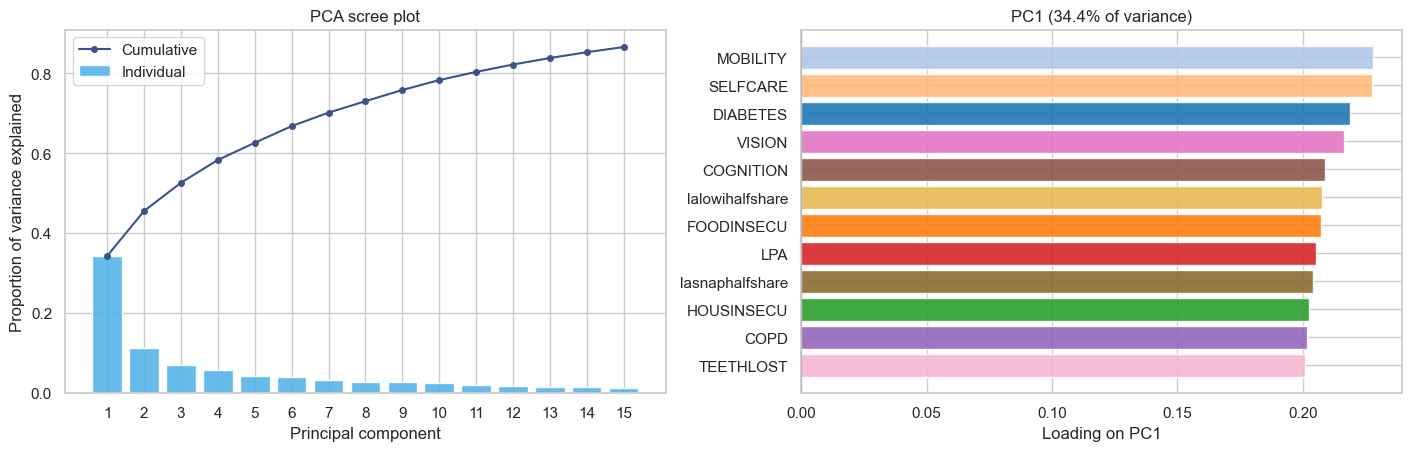

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), layout="constrained")

comps = np.arange(1, N_COMPONENTS + 1)
axes[0].bar(comps, pca.explained_variance_ratio_, color=VARIABLE_COLORS["individual_explained_variance"], alpha=0.9, label="Individual")
axes[0].plot(comps, np.cumsum(pca.explained_variance_ratio_), "o-", color=VARIABLE_COLORS["cumulative_explained_variance"],
             linewidth=1.5, markersize=4, label="Cumulative")
axes[0].set(xlabel="Principal component", ylabel="Proportion of variance explained",
            title="PCA scree plot", xticks=comps)
axes[0].legend()

# Which original predictors load most heavily on PC1?
loadings = pd.Series(pca.components_[0], index=selected).sort_values(key=abs, ascending=False)
top_load = loadings.head(12).iloc[::-1]
colors = [variable_color(feature) for feature in top_load.index]
axes[1].barh(top_load.index, top_load.values, color=colors, alpha=0.9)
axes[1].axvline(0, color=VARIABLE_COLORS["reference"], linewidth=0.8)
axes[1].set(xlabel="Loading on PC1", title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)")

fig.savefig(FIGURES_DIR / "pca_structure.png", dpi=150)
plt.show()

The left graph shows that the first principal component explains 34.4% of the variance. Each additional component explains a smaller amount, while the cumulative line gradually reaches 86.6% at the fifteenth component.

The right graph shows that mobility, self-care, diabetes, vision, and cognition have the largest loadings on the first component. This suggests that the first component mainly summarizes a shared pattern across health, disability, and social-condition measures. However, PCA loadings describe how variables form a component; they do not show causal effects or individual feature importance.

## 4. Model Screening with 5-Fold Cross-Validation

Six regression models are compared using the same five cross-validation folds. Each model uses the same preprocessing pipeline, including median imputation, scaling, Lasso feature selection, and PCA. Performance is measured using $R^2$, RMSE, and MAE. The average fitting time is also reported to compare computational cost.

**Six regressors are compared. Each is placed behind the same imputation, scaling, Lasso, and PCA steps.**

In [8]:
candidates = {
    "Linear Regression (baseline)": make_pipeline(LinearRegression()),
    "Ridge": make_pipeline(Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    "ElasticNet": make_pipeline(ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000,
                                           random_state=RANDOM_STATE)),
    "SVR (RBF)": make_pipeline(SVR(kernel="rbf", C=10.0, epsilon=0.1)),
    # Keep estimators and outer validation serial for stable notebook execution.
    "Random Forest": make_pipeline(RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                                         random_state=RANDOM_STATE, n_jobs=1)),
    "XGBoost": make_pipeline(XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                                          subsample=0.8, colsample_bytree=0.8,
                                          tree_method="hist", random_state=RANDOM_STATE,
                                          n_jobs=1, verbosity=0)),
}

SCORING = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

rows = []
for name, pipe in candidates.items():
    scores = cross_validate(pipe, X_train_model, y_train, cv=CV, scoring=SCORING, n_jobs=1)
    rows.append({
        "Model": name,
        "R2 (mean)": scores["test_r2"].mean(),
        "R2 (sd)": scores["test_r2"].std(),
        "RMSE": -scores["test_rmse"].mean(),
        "MAE": -scores["test_mae"].mean(),
        "Fit time (s)": scores["fit_time"].mean(),
    })
    print(f" {name}")

cv_results = (pd.DataFrame(rows)
              .sort_values("R2 (mean)", ascending=False)
              .reset_index(drop=True))
cv_results.round(4)

 Linear Regression (baseline)
 Ridge
 ElasticNet
 SVR (RBF)
 Random Forest
 XGBoost


,Model,R2 (mean),R2 (sd),RMSE,MAE,Fit time (s)
0,XGBoost,0.9166,0.0083,1.3489,1.0381,0.4922
1,SVR (RBF),0.9138,0.0128,1.3726,1.0206,0.1435
2,Random Forest,0.9029,0.0122,1.4540,1.1158,3.6277
3,ElasticNet,0.9005,0.0094,1.4743,1.1569,0.0539
4,Ridge,0.9001,0.0091,1.4772,1.1571,0.0556
5,Linear Regression (baseline),0.9001,0.0091,1.4772,1.1571,0.0573


XGBoost achieved the highest average $R^2$ of 0.9166 and the lowest RMSE of 1.3489. It also had the smallest $R^2$ standard deviation of 0.0083, suggesting consistent performance across the five folds.

SVR ranked second with an average $R^2$ of 0.9138. It had the lowest MAE of 1.0206, meaning that its average prediction error was slightly smaller than that of XGBoost. Random Forest performed reasonably well but required the longest fitting time.

Elastic Net, Ridge, and the linear regression baseline had similar results, with average $R^2$ scores close to 0.90. Overall, XGBoost provided the best balance of predictive performance and consistency, so it was selected for further tuning.

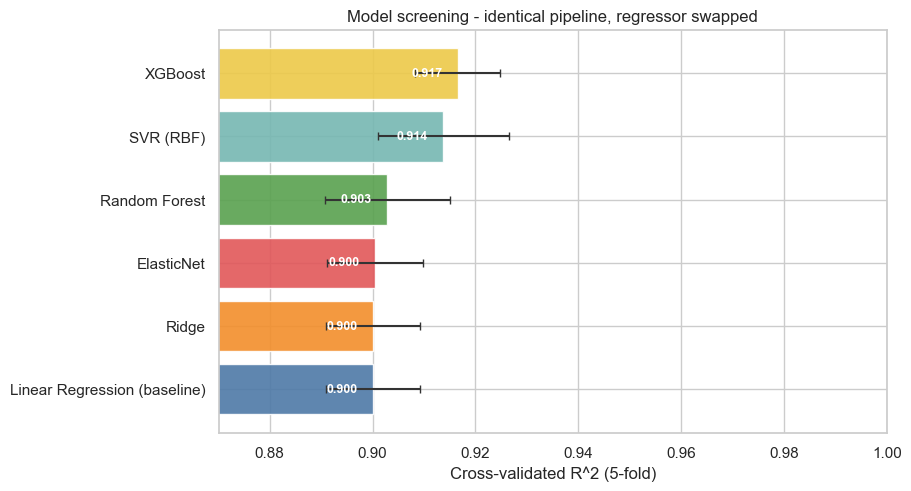

Baseline (Linear Regression): CV R2 = 0.9001
Best candidate: XGBoost (CV R2 = 0.9166, +0.0165 vs. baseline)


In [9]:
plot_df = cv_results.sort_values("R2 (mean)")

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
colors = [MODEL_COLORS[model] for model in plot_df["Model"]]
ax.barh(plot_df["Model"], plot_df["R2 (mean)"], xerr=plot_df["R2 (sd)"],
        color=colors, alpha=0.9, error_kw={"ecolor": "#333333", "capsize": 3})
ax.set_xlabel("Cross-validated R^2 (5-fold)")
ax.set_title("Model screening - identical pipeline, regressor swapped")
ax.set_xlim(max(0.0, plot_df["R2 (mean)"].min() - 0.03), 1.0)
for y_pos, value in enumerate(plot_df["R2 (mean)"]):
    ax.text(value - 0.003, y_pos, f"{value:.3f}", va="center", ha="right",
            fontsize=9, color="white", fontweight="bold")

fig.savefig(FIGURES_DIR / "model_comparison_r2.png", dpi=150)
plt.show()

best_name = cv_results.loc[0, "Model"]
baseline_r2 = cv_results.loc[cv_results["Model"].str.contains("baseline"), "R2 (mean)"].iloc[0]
print(f"Baseline (Linear Regression): CV R2 = {baseline_r2:.4f}")
print(f"Best candidate: {best_name} (CV R2 = {cv_results.loc[0, 'R2 (mean)']:.4f}, "
      f"{cv_results.loc[0, 'R2 (mean)'] - baseline_r2:+.4f} vs. baseline)")

The figure compares the average five-fold cross-validated $R^2$ scores of the six models. XGBoost performed best, with an $R^2$ of 0.9166, which is 0.0165 higher than the linear regression baseline. SVR ranked a close second with an $R^2$ of 0.9138, followed by Random Forest at 0.9029. Elastic Net, Ridge, and linear regression produced similar scores of about 0.90. Although the error bars overlap, XGBoost achieved the highest average score and was selected for further tuning.

### 4.1 Lasso and PCA ablation test
Does the Lasso selection + PCA block earn its place?

The block is a modeling choice, so it should be defended with a number rather than assumed. Here
each regressor is re-scored on the **imputed and scaled predictors directly**, with the Lasso gate
and PCA removed and nothing else changed.

This also demonstrates why the block exists at all: unregularised OLS on the raw 79 predictors is
numerically unstable — the food-access families (`la*halfshare` vs. `la*1share` measure the same
populations at two distance thresholds) leave the design matrix near-singular. Compressing to 15
orthogonal components is exactly what makes the baseline well-posed.

In [10]:
# Component counts are capped per alpha so no fold can request more components than it has features
SHARED_GRIDS = [
    {"feature_selection__estimator__alpha": [0.0055, 0.01], "pca__n_components": [10, 15, 25]},
    {"feature_selection__estimator__alpha": [0.05], "pca__n_components": [10, 15, 20]},
]

REGRESSOR_GRIDS = {
    "Linear Regression (baseline)": {},
    "Ridge": {"regressor__alpha": [0.1, 1.0, 10.0]},
    "ElasticNet": {"regressor__alpha": [0.005, 0.01, 0.05], "regressor__l1_ratio": [0.2, 0.5, 0.8]},
    "SVR (RBF)": {"regressor__C": [1.0, 10.0, 50.0], "regressor__epsilon": [0.05, 0.1, 0.3]},
    "Random Forest": {"regressor__n_estimators": [400, 800], "regressor__min_samples_leaf": [1, 2, 5]},
    "XGBoost": {"regressor__learning_rate": [0.03, 0.05, 0.1],
                "regressor__n_estimators": [300, 600],
                "regressor__max_depth": [4, 6, 8]},
}

param_grid = [{**shared, **REGRESSOR_GRIDS[best_name]} for shared in SHARED_GRIDS]

grid = GridSearchCV(candidates[best_name], param_grid=param_grid, scoring="r2",
                    cv=CV, n_jobs=1, refit=True, verbose=1, error_score="raise")
grid.fit(X_train_model, y_train)

best_model = grid.best_estimator_
print(f"\nTuned {best_name}")
for param, value in sorted(grid.best_params_.items()):
    print(f"  {param}: {value}")
print(f"Best cross-validated R2: {grid.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits

Tuned XGBoost
  feature_selection__estimator__alpha: 0.05
  pca__n_components: 20
  regressor__learning_rate: 0.03
  regressor__max_depth: 4
  regressor__n_estimators: 600
Best cross-validated R2: 0.9360


The best tuning result was achieved by XGBoost with a Lasso alpha of 0.05 and 20 PCA components. The final model used a learning rate of 0.03, a maximum tree depth of 4, and 600 trees. It achieved an average cross-validated ($R^2$) of 0.9360, meaning that the model explained about 93.6% of the variation in the outcome across the validation folds. 

In [11]:
tuning_table = (pd.DataFrame(grid.cv_results_)
                .loc[:, ["params", "mean_test_score", "std_test_score", "rank_test_score"]]
                .sort_values("rank_test_score")
                .head(10)
                .reset_index(drop=True))
tuning_table.round(4)

,params,mean_test_score,std_test_score,rank_test_score
0,"{'feature_selection__estimator__alpha': 0.05, ...",0.9360,0.0097,1
1,"{'feature_selection__estimator__alpha': 0.05, ...",0.9346,0.0100,2
2,"{'feature_selection__estimator__alpha': 0.05, ...",0.9335,0.0101,3
3,"{'feature_selection__estimator__alpha': 0.05, ...",0.9326,0.0098,4
4,"{'feature_selection__estimator__alpha': 0.05, ...",0.9320,0.0101,5
5,"{'feature_selection__estimator__alpha': 0.05, ...",0.9314,0.0100,6
6,"{'feature_selection__estimator__alpha': 0.05, ...",0.9314,0.0100,7
7,"{'feature_selection__estimator__alpha': 0.01, ...",0.9312,0.0096,8
8,"{'feature_selection__estimator__alpha': 0.01, ...",0.9309,0.0102,9
9,"{'feature_selection__estimator__alpha': 0.05, ...",0.9309,0.0099,10


The table shows the ten best parameter combinations from the tuning process. Their average cross-validated ($R^2$) scores range from 0.9309 to 0.9360, so all ten combinations perform well. The best combination ranks first with an ($R^2$) of 0.9360. The standard deviations are close to 0.01, which suggests that the results are consistent across the validation folds. Since the scores are very close, the model’s performance is not highly sensitive to small changes in the selected parameters.

## 6. Held-Out Test Evaluation
After tuning, the final XGBoost model is evaluated on the held-out test set. This test set was not used for model training or parameter tuning, so it provides a fair measure of how well the model performs on new data. The final model is evaluated using $R^2$, RMSE, and MAE, and its results are compared with the linear regression baseline.

In [12]:
y_pred_train = best_model.predict(X_train_model)
y_pred_test = best_model.predict(X_test_model)


def score_row(y_true, y_pred, label):
    return {"Split": label,
            "R2": r2_score(y_true, y_pred),
            "RMSE": root_mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred)}


# Baseline scored on the same test split, for the headline comparison
baseline_fitted = make_pipeline(LinearRegression()).fit(X_train_model, y_train)
y_pred_baseline = baseline_fitted.predict(X_test_model)

final_scores = pd.DataFrame([
    score_row(y_train, y_pred_train, f"{best_name} - train (in-sample)"),
    {"Split": f"{best_name} - train (5-fold CV)", "R2": grid.best_score_, "RMSE": np.nan, "MAE": np.nan},
    score_row(y_test, y_pred_test, f"{best_name} - TEST (held-out)"),
    score_row(y_test, y_pred_baseline, "Linear Regression baseline - TEST (held-out)"),
])
final_scores.round(4)

,Split,R2,RMSE,MAE
0,XGBoost - train (in-sample),0.9831,0.6101,0.4710
1,XGBoost - train (5-fold CV),0.9360,NaN,NaN
2,XGBoost - TEST (held-out),0.9271,1.2117,0.9278
3,Linear Regression baseline - TEST (held-out),0.8959,1.4476,1.1200


The final XGBoost model achieved a test $R^2$ of 0.9271, meaning that it explained about 92.7% of the variation in the held-out data. Its test RMSE was 1.2117 and its MAE was 0.9278.

The test $R^2$ is lower than the training $R^2$of 0.9831 and slightly lower than the cross-validation $R^2$ of 0.9360. This suggests some overfitting, but the model still performs well on unseen data.

XGBoost also performed better than the linear regression baseline, which had a test $R^2$ of 0.8959, an RMSE of 1.4476, and an MAE of 1.1200. Overall, XGBoost explains more variation and produces smaller prediction errors, making it the stronger final model.

### 6.1 Predicted vs. actual and residual diagnostics

The following plots provide a closer look at the final model’s performance on the held-out test set. The predicted values are compared with the actual values, and the residuals are examined to identify possible bias, unusual patterns, or changes in prediction error. A well-performing model should produce predictions close to the 45-degree line, while its residuals should be randomly spread around zero.

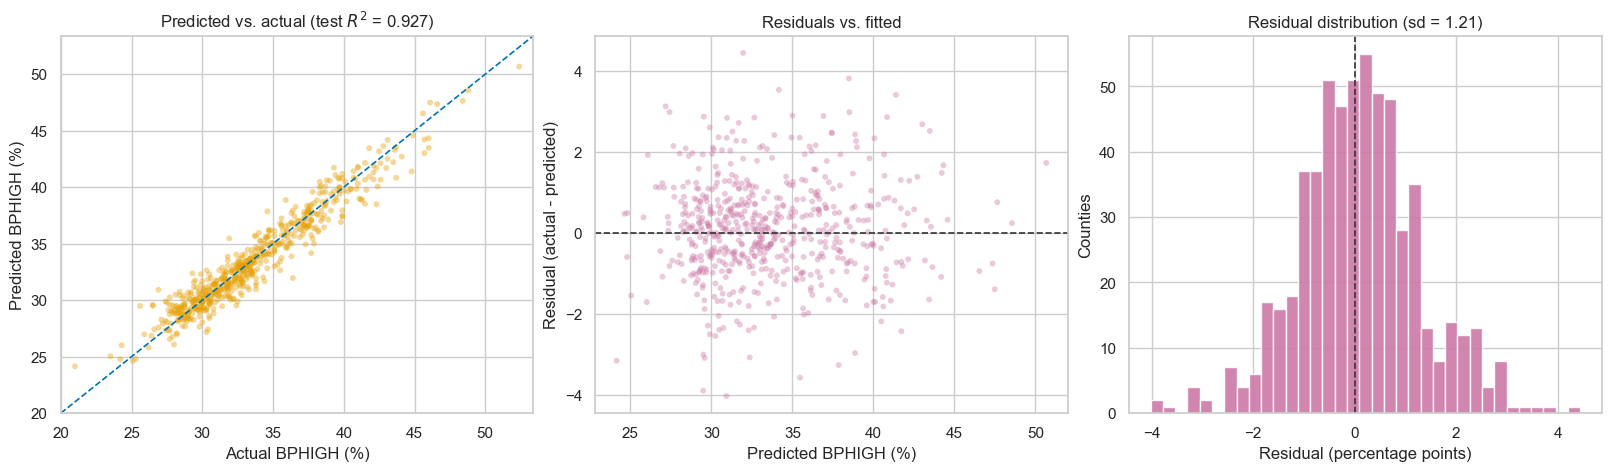

Counties predicted within 1 percentage point: 65.0%
Counties predicted within 2 percentage points: 88.9%


In [13]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), layout="constrained")

axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=18, color=VARIABLE_COLORS["predicted_BPHIGH"], edgecolor="none")
lims = [min(y_test.min(), y_pred_test.min()) - 1, max(y_test.max(), y_pred_test.max()) + 1]
axes[0].plot(lims, lims, "--", color=VARIABLE_COLORS["BPHIGH"], linewidth=1.2)
axes[0].set(xlim=lims, ylim=lims, xlabel="Actual BPHIGH (%)", ylabel="Predicted BPHIGH (%)",
            title=f"Predicted vs. actual (test $R^2$ = {r2_score(y_test, y_pred_test):.3f})")

axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=18, color=VARIABLE_COLORS["residual"], edgecolor="none")
axes[1].axhline(0, linestyle="--", color=VARIABLE_COLORS["reference"], linewidth=1.2)
axes[1].set(xlabel="Predicted BPHIGH (%)", ylabel="Residual (actual - predicted)",
            title="Residuals vs. fitted")

axes[2].hist(residuals, bins=35, color=VARIABLE_COLORS["residual"], alpha=0.9)
axes[2].axvline(0, linestyle="--", color=VARIABLE_COLORS["reference"], linewidth=1.2)
axes[2].set(xlabel="Residual (percentage points)", ylabel="Counties",
            title=f"Residual distribution (sd = {residuals.std():.2f})")

fig.savefig(FIGURES_DIR / "test_diagnostics.png", dpi=150)
plt.show()

print(f"Counties predicted within 1 percentage point: {(residuals.abs() <= 1).mean():.1%}")
print(f"Counties predicted within 2 percentage points: {(residuals.abs() <= 2).mean():.1%}")

The left chart shows the predicted values are closely grouped around the 45-degree line, which agrees with the strong test `$R^2$` of 0.927. This means that the model’s predictions are generally close to the actual county values.

The center graph shows the residuals are mostly centered around zero and do not show a strong curve or funnel-shaped pattern. This suggests that the model does not have a major systematic bias and that its prediction errors are fairly consistent across the fitted range. However, a few larger errors are present, especially near the lowest and highest values.

The right graphic shows the residual distribution is also centered near zero, with a standard deviation of about 1.21 percentage points. Overall, 65.0% of counties are predicted within one percentage point of their actual value, while 88.9% are predicted within two percentage points. These results show that the final model provides accurate and reasonably consistent predictions for most counties.

### 6.2 Largest errors
To better understand where the model has difficulty, the ten counties with the largest absolute prediction errors are examined. The residual is calculated as the actual value minus the predicted value. A positive residual means the model predicted too low, while a negative residual means it predicted too high.

In [14]:
predictions = test_ids.copy()
predictions["actual"] = y_test.values
predictions["predicted"] = y_pred_test
predictions["residual"] = predictions["actual"] - predictions["predicted"]
predictions["abs_error"] = predictions["residual"].abs()

predictions.sort_values("abs_error", ascending=False).head(10).round(3)

,fipscode,locationname,stateabbr,State,County,actual,predicted,residual,abs_error
389,5143,Washington,AR,Arkansas,Washington County,36.4,31.955000,4.445,4.445
54,27135,Roseau,MN,Minnesota,Roseau County,26.9,30.922001,-4.022,4.022
533,27111,Otter Tail,MN,Minnesota,Otter Tail County,25.6,29.489000,-3.889,3.889
400,13315,Wilcox,GA,Georgia,Wilcox County,42.3,38.485001,3.815,3.815
223,23025,Somerset,ME,Maine,Somerset County,31.9,35.471001,-3.571,3.571
92,54079,Putnam,WV,West Virginia,Putnam County,37.7,34.167000,3.533,3.533
42,47075,Haywood,TN,Tennessee,Haywood County,44.8,41.390999,3.409,3.409
29,36005,Bronx,NY,New York,Bronx County,34.6,37.858002,-3.258,3.258
239,8013,Boulder,CO,Colorado,Boulder County,21.0,24.152000,-3.152,3.152
119,11001,District of Columbia,DC,District of Columbia,District of Columbia,30.3,27.174000,3.126,3.126


Washington County, Arkansas, has the largest error, with the model underpredicting its actual value by about 4.45 percentage points. Roseau County, Minnesota, has the second-largest error, with an overprediction of about 4.02 percentage points. The other absolute errors range from about 3.13 to 3.89 percentage points.

The errors include both overpredictions and underpredictions, so there is no clear direction of bias. These counties may have unusual local conditions or data-quality issues that are not fully captured by the model. In addition, median imputation may replace missing information with typical values, making counties with high missingness or unusual characteristics harder to predict.

## 7. Feature Importance

PCA components are not interpretable in their own right, so importance is measured on the
**original predictors**: each raw column is shuffled and pushed through the entire fitted pipeline
(selection and PCA included), and the drop in test R² is recorded. This keeps the results in
feature space while respecting the pipeline actually being used.

Permutation importance is used to identify which original predictors contribute most to the final XGBoost model. Each feature is randomly shuffled, and the resulting decrease in test $R^2$ is measured. A larger decrease means that the model depends more strongly on that feature. The error bars show how much the importance score changes across repeated shuffles.

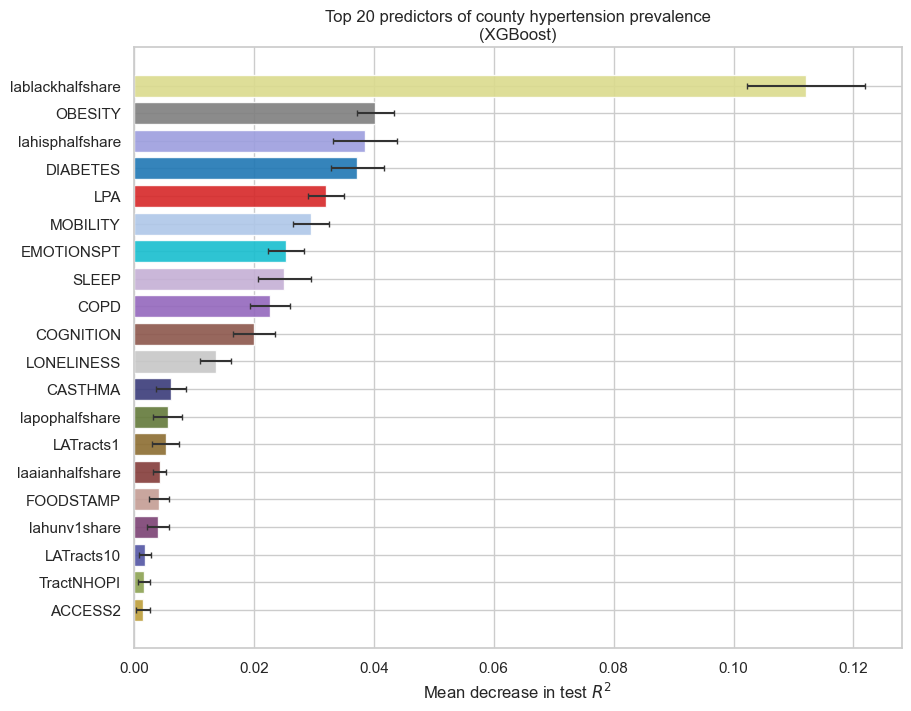

,feature,importance,std
0,lablackhalfshare,0.1121,0.0098
1,OBESITY,0.0402,0.0031
2,lahisphalfshare,0.0385,0.0054
3,DIABETES,0.0373,0.0045
4,LPA,0.0320,0.0030
5,MOBILITY,0.0296,0.0030
6,EMOTIONSPT,0.0253,0.0030
7,SLEEP,0.0251,0.0044
8,COPD,0.0227,0.0033
9,COGNITION,0.0200,0.0035


In [15]:
perm = permutation_importance(best_model, X_test_model, y_test, n_repeats=15,
                              random_state=RANDOM_STATE, n_jobs=1, scoring="r2")

importance = (pd.DataFrame({"feature": FEATURES,
                            "importance": perm.importances_mean,
                            "std": perm.importances_std})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))

top = importance.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
importance_colors = [variable_color(feature) for feature in top["feature"]]
ax.barh(top["feature"], top["importance"], xerr=top["std"], color=importance_colors, alpha=0.9,
        error_kw={"ecolor": "#333333", "capsize": 2})
ax.set_xlabel("Mean decrease in test $R^2$")
ax.set_title(f"Top 20 predictors of county hypertension prevalence\n({best_name})")
fig.savefig(FIGURES_DIR / "permutation_importance.png", dpi=150)
plt.show()

importance.head(20).round(4)

The most important predictor is lablackhalfshare, with an average decrease in test $R^2$ of 0.1121 when shuffled. Its importance is much higher than that of the other predictors, suggesting that the model relies strongly on this feature.

Obesity, lahisphalfshare, diabetes, limited physical activity, and mobility form the next group of important predictors. Emotional support, sleep, COPD, cognition, and loneliness also contribute to the model, but to a smaller degree. The remaining features have relatively low importance scores.

Overall, the results suggest that county hypertension predictions depend on a combination of food-access, demographic, health, and social factors. However, these scores show how useful each feature is for prediction, not whether it increases or decreases hypertension. They also do not prove a causal relationship, and correlated features may share importance with one another.

### 7.1 CDC PLACES co-morbidity sensitivity analysis
How accurately can hypertension burden be estimated without relying on related CDC health estimates?

The co-morbidity variables (`DIABETES`, `MOBILITY`, `COPD`, `OBESITY`, ...) dominate the ranking.
Before reporting that as a finding, note what they are: **CDC PLACES model-based estimates**,
produced by the same small-area estimation procedure, from the same BRFSS survey, using overlapping
demographic and geographic predictors as `BPHIGH` itself. Part of the measured association is
shared estimation methodology rather than independent epidemiological signal.

For the risk-atlas use case this matters concretely — if the goal is to predict hypertension burden
where PLACES estimates are *unavailable*, the co-morbidity block will not be available either. The
cell below refits on the social, economic and food-access predictors only. The gap between the two
is the honest measure of what the social determinants contribute on their own, and both belong in
the paper.

In [16]:
CDC_BLOCK = ["ACCESS2", "CASTHMA", "COGNITION", "COPD", "CSMOKING", "DIABETES", "EMOTIONSPT",
             "FOODINSECU", "FOODSTAMP", "GHLTH", "HOUSINSECU", "LONELINESS", "LPA", "MOBILITY",
             "OBESITY", "SELFCARE", "SLEEP", "TEETHLOST", "VISION"]
cdc_present = [c for c in CDC_BLOCK if c in FEATURES]

X_sdoh = X_train_model.drop(columns=cdc_present)

tuned_alpha = grid.best_params_.get("feature_selection__estimator__alpha", LASSO_ALPHA)
tuned_n = grid.best_params_.get("pca__n_components", N_COMPONENTS)

# The tuned component count assumed all 79 predictors. With the CDC block removed the Lasso gate
# keeps fewer, so cap n_components at the smallest per-fold selection - otherwise some folds cannot
# be fit and quietly score as NaN.
probe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("feature_selection", SelectFromModel(Lasso(alpha=tuned_alpha, max_iter=10000,
                                                random_state=RANDOM_STATE))),
])
per_fold = [probe.fit(X_sdoh.iloc[tr], y_train.iloc[tr])
                 .named_steps["feature_selection"].get_support().sum()
            for tr, _ in CV.split(X_sdoh)]
n_components_sdoh = int(min(tuned_n, min(per_fold)))
print(f"Lasso keeps {min(per_fold)}-{max(per_fold)} of {X_sdoh.shape[1]} predictors per fold "
      f"-> using n_components={n_components_sdoh} (tuned model used {tuned_n})\n")

sdoh_pipeline = make_pipeline(clone(best_model.named_steps["regressor"]),
                              alpha=tuned_alpha, n_components=n_components_sdoh)
sdoh_scores = cross_validate(sdoh_pipeline, X_sdoh, y_train, cv=CV, scoring=SCORING,
                             n_jobs=1, error_score="raise")

print(f"With CDC co-morbidity block    ({len(FEATURES)} predictors): "
      f"CV R2 = {grid.best_score_:.4f}")
print(f"Without CDC co-morbidity block ({X_sdoh.shape[1]} predictors): "
      f"CV R2 = {sdoh_scores['test_r2'].mean():.4f}, RMSE = {-sdoh_scores['test_rmse'].mean():.4f}")

Lasso keeps 19-26 of 60 predictors per fold -> using n_components=19 (tuned model used 20)

With CDC co-morbidity block    (79 predictors): CV R2 = 0.9360
Without CDC co-morbidity block (60 predictors): CV R2 = 0.8154, RMSE = 2.0097


With the CDC co-morbidity variables included, the model achieved a cross-validated $R^2$ of 0.9360. After these variables were removed, the cross-validated $R^2$ decreased to 0.8154, with an RMSE of 2.0097. This drop shows that the related CDC health estimates provide substantial predictive information.

However, the reduced model still explains about 81.5% of the variation in county hypertension prevalence. This suggests that social, economic, demographic, and food-access factors remain useful predictors even without the related health estimates. The lower performance also provides a more realistic estimate for situations where if CDC co-morbidity data are unavailable.

## 8. SHAP

SHapley Additive exPlanations (SHAP) is a method used to explain why a machine learning model makes a particular prediction. It assigns each feature an importance value for a specific prediction, allowing us to understand the contribution of each feature to the model's output. Using SHAP bridges the performance and explainability gap, providing insights into the model's decision-making process, allowing for an understanding of the underlying drivers of hypertension prevalence.

PermutationExplainer explainer: 593it [01:40,  5.43it/s]                         


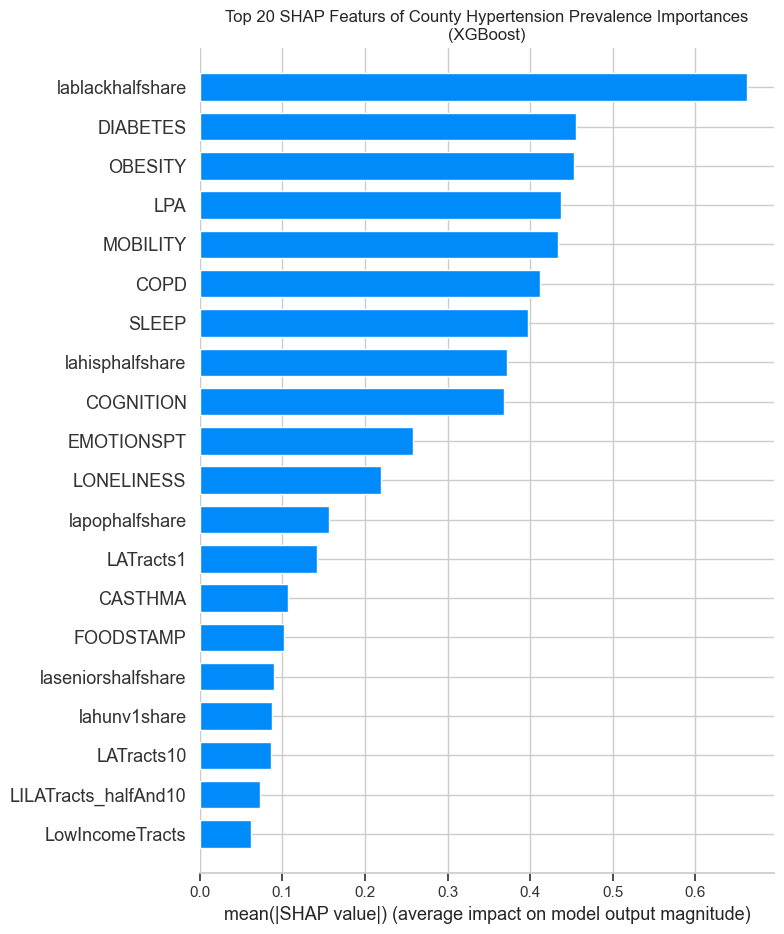

In [17]:
# Define a background dataset for SHAP explainer.
background_data = X_train_model.sample(n=min(100, len(X_train_model)), random_state=42)

# Initialize SHAP Explainer using the pipeline's predict method.
explainer = shap.Explainer(best_model.predict, background_data)

# Calculate SHAP values for your test set (or evaluation set)
shap_values = explainer(X_test_model)

# Generate a global SHAP summary bar plot (akin to your top 20 feature importance plot) 
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test_model, plot_type="bar", max_display=20, show=False)
plt.title(f"Top 20 SHAP Featurs of County Hypertension Prevalence Importances\n({best_name})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary_importance.png", dpi=150)
plt.show()

The Figure shows the mean absolute SHAP values for each feature across all predictions, explaing the overall magnitude of importance.

Features are ranked from top to bottom with the most impactful at the top. In this case lablackshare is the top feature with a mean SHAP value over 0.6. The rest of the top five features are obesity, diabeties, mobility, and LPA with mean SHAP values between 0.4 and 0.5. The five features witht he lowest mean SHAP value are LowIncomeTracts, LILATracts_haldAnd10, Lahunv1share, LATracts10, and laseniorshalfshare, all of which have mean SHAP values under 0.1.

Feature lablackshare is, on average, the strongest driver of model predictions, shifting the baseline estimate by the model's target units across counties.

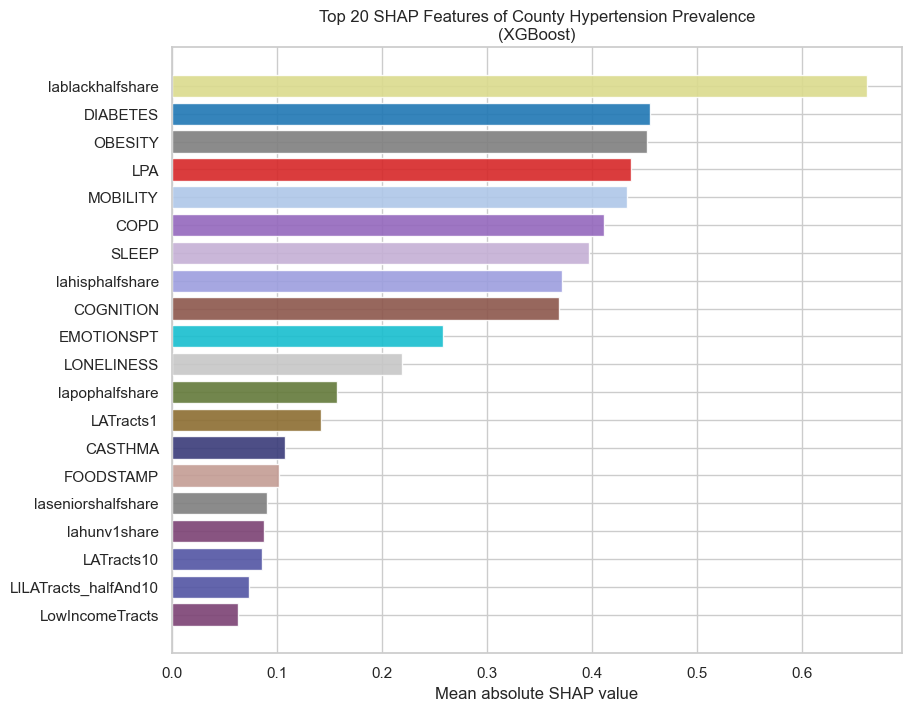

In [ ]:
# Apply color mapping to the SHAP summary plot for consistency with previous plots

# Extract mean absolute SHAP values manually for the top 20 features
# shap_values.values shape is (samples, features)
mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)
shap_importance_df = pd.DataFrame({
    "feature": X_test_model.columns,
    "importance": mean_abs_shap
}).sort_values("importance", ascending=True) # Ascending so the largest is at the top in barh

# Get the top 20 features
top_shap = shap_importance_df.tail(20)

# 3. Map colors to these specific features
shap_colors = [variable_color(feature) for feature in top_shap["feature"]]

# 4. Plot using standard matplotlib barh (matching your permutation plot style)
fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
ax.barh(top_shap["feature"], top_shap["importance"], color=shap_colors, alpha=0.9)

ax.set_xlabel("Mean absolute SHAP value")
ax.set_title(f"Top 20 SHAP Features of County Hypertension Prevalence\n({best_name})")

fig.savefig(FIGURES_DIR / "shap_summary_importance_col.png", dpi=150)
plt.show()

## 9. Persist Artifacts
The final model and its supporting results are saved for future use. The complete fitted pipeline is stored as one object, including median imputation, scaling, Lasso feature selection, PCA, and the tuned XGBoost model. This allows new county data to be processed and predicted in the same way as the training data.

*Note. SHAP figure is saved in section 8.*

In [19]:
model_path = MODELS_DIR / "hypertension_model.joblib"
joblib.dump(best_model, model_path)

cv_results.to_csv(DATA_FINAL / "model_comparison.csv", index=False)
predictions.drop(columns="abs_error").to_csv(DATA_FINAL / "model_test_predictions.csv", index=False)
importance.to_csv(DATA_FINAL / "feature_importance.csv", index=False)

print(f"Model              -> models/hypertension_model.joblib")
print(f"CV comparison      -> data/final/model_comparison.csv")
print(f"Test predictions   -> data/final/model_test_predictions.csv")
print(f"Feature importance -> data/final/feature_importance.csv")
print(f"SHAP importance       -> data/final/shap_feature_importance_col.csv")
print(f"Figures            -> notebooks/05_Modeling/figures/")

Model              -> models/hypertension_model.joblib
CV comparison      -> data/final/model_comparison.csv
Test predictions   -> data/final/model_test_predictions.csv
Feature importance -> data/final/feature_importance.csv
SHAP importance       -> data/final/shap_feature_importance_col.csv
Figures            -> notebooks/05_Modeling/figures/


The saved model can be loaded to make predictions without repeating the training or preprocessing steps. The model comparison results, held-out test predictions, feature-importance scores, and figures are also saved as separate files. These outputs support reproducibility and make it easier to review the results, create reports, or apply the model to new county data.

In [20]:
# Reload check: the saved pipeline must reproduce the reported test score exactly
reloaded = joblib.load(model_path)
assert np.allclose(reloaded.predict(X_test_model), y_pred_test), "Reloaded model does not match"
print(f"Reload verified - test R2 = {r2_score(y_test, reloaded.predict(X_test_model)):.4f}")

Reload verified - test R2 = 0.9271


## 10. Summary

| Item | Value |
| --- | --- |
| Task | Regression on `BPHIGH` (% adults with high blood pressure, county level) |
| Training counties | 2,364 |
| Test counties | 592 |
| Predictors | 79 numeric (identifiers excluded) |
| Pipeline | Impute → Scale → Lasso selection → PCA → regressor |
| Baseline | Linear Regression through the same pipeline (section 4) |
| Selected model | Winner of section 4 XGBoost, tuned in section 5 |
| Headline numbers | Section 6 — baseline and tuned model on the same held-out split |

**Artifacts written**

| Path | Contents |
| --- | --- |
| `models/hypertension_model.joblib` | Fitted pipeline, all five steps |
| `data/final/model_comparison.csv` | 5-fold CV screening table |
| `data/final/model_test_predictions.csv` | Per-county test predictions with FIPS, for mapping |
| `data/final/feature_importance.csv` | Permutation importance, all predictors |
| `data/final/feature_importance.csv` | Permutation importance, all predictors |
| `data/final/shap_feature_importance_col.csv` | SHAP feature importance, all predictors |
| `notebooks/05_Modeling/figures/` | PCA structure, model comparison, diagnostics, importance |

**Next steps**
- Act on the section 7.1 caveat: promote the no-CDC-block model to a second headline result if the
  atlas is meant to generalise to counties without PLACES estimates
- Check whether residuals cluster geographically — that would motivate a spatial term or a
  `GroupKFold` split by state
- Feed `data/final/model_test_predictions.csv` into the risk-atlas choropleth